<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/04_feature_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Define paths and imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [11]:
# Load block-level count vectors
df_blocks = pd.read_parquet(DATA_PROC / "hdfs_block_vectors.parquet")
print(f"Shape: {df_blocks.shape}")

Shape: (575061, 56)


First analysis — compare total log lines per block, Normal vs Anomaly

In [12]:
# Calculate total log lines per block and compare Normal vs Anomaly
df_blocks["total_lines"] = df_blocks.drop(columns=["Label"]).sum(axis=1)

print("Normal blocks:")
print(df_blocks[df_blocks["Label"] == "Normal"]["total_lines"].describe())
print("\nAnomaly blocks:")
print(df_blocks[df_blocks["Label"] == "Anomaly"]["total_lines"].describe())

Normal blocks:
count    558223.000000
mean         19.503637
std           4.775583
min          13.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: total_lines, dtype: float64

Anomaly blocks:
count    16838.000000
mean        17.119017
std         12.409644
min          2.000000
25%          4.000000
50%         20.000000
75%         26.000000
max        284.000000
Name: total_lines, dtype: float64


Normal blocks:

Very consistent — almost always 19-20 lines
min = 13, very stable
Anomaly blocks:

Much more varied (std = 12.4 vs 4.8)
min = 2 lines — some blocks barely started before failing
25% have only 4 lines — incomplete lifecycle
Insight: A block with very few lines (< 13) is almost certainly anomalous. And a block with high variance in line count is suspicious.

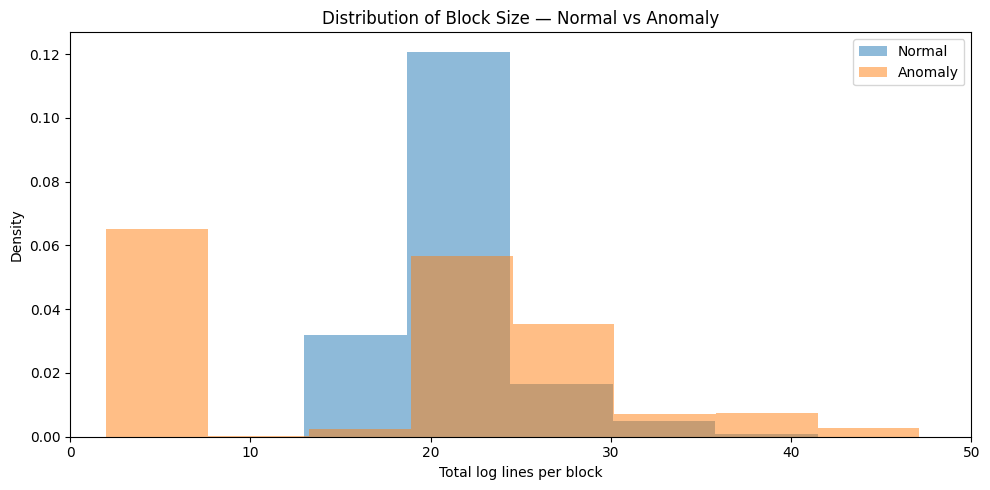

In [13]:
# Plot distribution of total lines per block — Normal vs Anomaly
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_blocks[df_blocks["Label"] == "Normal"]["total_lines"], bins=50, alpha=0.5, label="Normal", density=True)
ax.hist(df_blocks[df_blocks["Label"] == "Anomaly"]["total_lines"], bins=50, alpha=0.5, label="Anomaly", density=True)
ax.set_xlabel("Total log lines per block")
ax.set_ylabel("Density")
ax.set_title("Distribution of Block Size — Normal vs Anomaly")
ax.legend()
ax.set_xlim(0, 50)
plt.tight_layout()
plt.savefig(str(RESULTS / "block_size_distribution.png"), dpi=150)
plt.show()

 how many different template types appear in each block (not how many times, just whether they appear or not). For example, if a block has templates 1, 4, and 5 — unique_templates = 3. A normal block should have a consistent set of templates, while an anomaly block might have fewer (failed early) or different ones.

In [14]:
# Count unique templates per block and compare Normal vs Anomaly
template_cols = [c for c in df_blocks.columns if c.startswith("t_")]
df_blocks["unique_templates"] = (df_blocks[template_cols] > 0).sum(axis=1)

print("Normal blocks:")
print(df_blocks[df_blocks["Label"] == "Normal"]["unique_templates"].describe())
print("\nAnomaly blocks:")
print(df_blocks[df_blocks["Label"] == "Anomaly"]["unique_templates"].describe())

Normal blocks:
count    558223.000000
mean          7.290352
std           1.508695
min           5.000000
25%           7.000000
50%           7.000000
75%           8.000000
max          15.000000
Name: unique_templates, dtype: float64

Anomaly blocks:
count    16838.000000
mean         7.204834
std          3.980863
min          2.000000
25%          3.000000
50%          8.000000
75%         11.000000
max         24.000000
Name: unique_templates, dtype: float64


Normal blocks: very consistent — almost always 7-8 unique templates (std = 1.5).

Anomaly blocks: much more spread out (std = 4.0):

Some have only 2-3 templates (failed early)
Some have 11+ templates (error/replication templates added)
Same pattern as total_lines — anomaly blocks are less predictable.

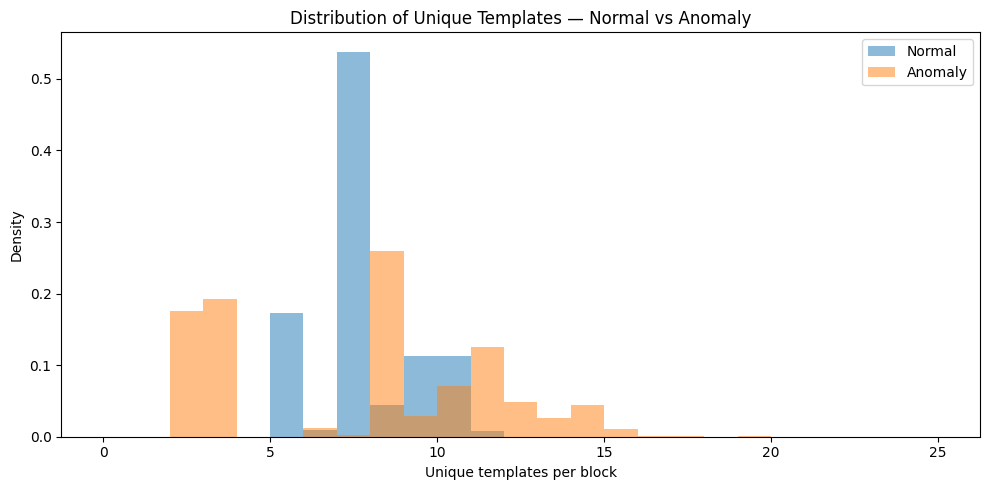

In [15]:
# Plot distribution of unique templates per block — Normal vs Anomaly
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_blocks[df_blocks["Label"] == "Normal"]["unique_templates"], bins=range(0, 26), alpha=0.5, label="Normal", density=True)
ax.hist(df_blocks[df_blocks["Label"] == "Anomaly"]["unique_templates"], bins=range(0, 26), alpha=0.5, label="Anomaly", density=True)
ax.set_xlabel("Unique templates per block")
ax.set_ylabel("Density")
ax.set_title("Distribution of Unique Templates — Normal vs Anomaly")
ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "unique_templates_distribution.png"), dpi=150)
plt.show()

Template	Normal	Anomaly	Meaning
t_32	0.0%	30.4%	Error deleting block — strongest indicator
t_6	0.3%	20.6%	Received block with explicit size
t_11	0.3%	20.3%	Ask to replicate block
t_12	0.3%	20.3%	Starting thread to transfer block
t_16	0.0%	19.2%	Suspicious template
t_37	0.0%	9.8%	Suspicious template
t_33	0.0%	7.4%	Suspicious template
These templates almost never appear in normal blocks — they are strong anomaly indicators

In [16]:
# Find templates that appear mostly in anomaly blocks
for col in template_cols:
    normal_has = (df_blocks[df_blocks["Label"] == "Normal"][col] > 0).mean()
    anomaly_has = (df_blocks[df_blocks["Label"] == "Anomaly"][col] > 0).mean()
    if anomaly_has > normal_has * 2:
        print(f"{col}: Normal {normal_has:.1%}, Anomaly {anomaly_has:.1%}")

t_6: Normal 0.3%, Anomaly 20.6%
t_7: Normal 0.0%, Anomaly 0.9%
t_8: Normal 0.0%, Anomaly 0.4%
t_9: Normal 0.0%, Anomaly 0.4%
t_11: Normal 0.3%, Anomaly 20.3%
t_12: Normal 0.3%, Anomaly 20.3%
t_14: Normal 0.0%, Anomaly 0.3%
t_15: Normal 0.0%, Anomaly 0.1%
t_16: Normal 0.0%, Anomaly 19.2%
t_18: Normal 0.0%, Anomaly 2.9%
t_19: Normal 0.0%, Anomaly 0.3%
t_20: Normal 0.0%, Anomaly 0.0%
t_21: Normal 0.0%, Anomaly 5.8%
t_22: Normal 0.0%, Anomaly 0.2%
t_23: Normal 0.0%, Anomaly 0.2%
t_24: Normal 0.0%, Anomaly 0.2%
t_25: Normal 0.0%, Anomaly 0.2%
t_26: Normal 0.0%, Anomaly 0.2%
t_27: Normal 0.0%, Anomaly 0.1%
t_28: Normal 0.0%, Anomaly 0.0%
t_29: Normal 0.0%, Anomaly 0.1%
t_30: Normal 0.0%, Anomaly 0.1%
t_32: Normal 0.0%, Anomaly 30.4%
t_33: Normal 0.0%, Anomaly 7.4%
t_37: Normal 0.0%, Anomaly 9.8%
t_39: Normal 0.0%, Anomaly 0.0%
t_40: Normal 0.0%, Anomaly 0.1%
t_41: Normal 0.0%, Anomaly 0.0%
t_42: Normal 0.0%, Anomaly 0.1%
t_43: Normal 0.0%, Anomaly 0.0%
t_44: Normal 0.0%, Anomaly 0.3%
t_45: N

 time-based

In [17]:
# Load full parsed data to extract timestamps
df_full = pd.read_parquet(DATA_PROC / "hdfs_full_parsed.parquet")
print(df_full["log_line"].iloc[0])

081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010


Extract the timestamp and calculate how long each block takes from first to last log line.
Extracts the timestamp from each line, then for each block calculates how many seconds passed between the first and last log line

In [18]:
# Extract timestamp from each log line and calculate block duration
df_full["timestamp"] = pd.to_datetime(df_full["log_line"].str[:13], format="%y%m%d %H%M%S")

# Calculate duration per block (seconds between first and last line)
block_time = df_full.groupby("block_id")["timestamp"].agg(["min", "max"])
block_time["duration_seconds"] = (block_time["max"] - block_time["min"]).dt.total_seconds()

# Add labels
block_labels = df_full.groupby("block_id")["Label"].first()
block_time["Label"] = block_labels

print("Normal blocks duration:")
print(block_time[block_time["Label"] == "Normal"]["duration_seconds"].describe())
print("\nAnomaly blocks duration:")
print(block_time[block_time["Label"] == "Anomaly"]["duration_seconds"].describe())

Normal blocks duration:
count    558223.000000
mean      16870.912341
std       17865.694194
min           0.000000
25%        1241.000000
50%        7303.000000
75%       33732.000000
max       54025.000000
Name: duration_seconds, dtype: float64

Anomaly blocks duration:
count    16838.000000
mean     14089.464960
std      18376.636894
min          0.000000
25%          3.000000
50%       4920.500000
75%      31717.500000
max      53924.000000
Name: duration_seconds, dtype: float64


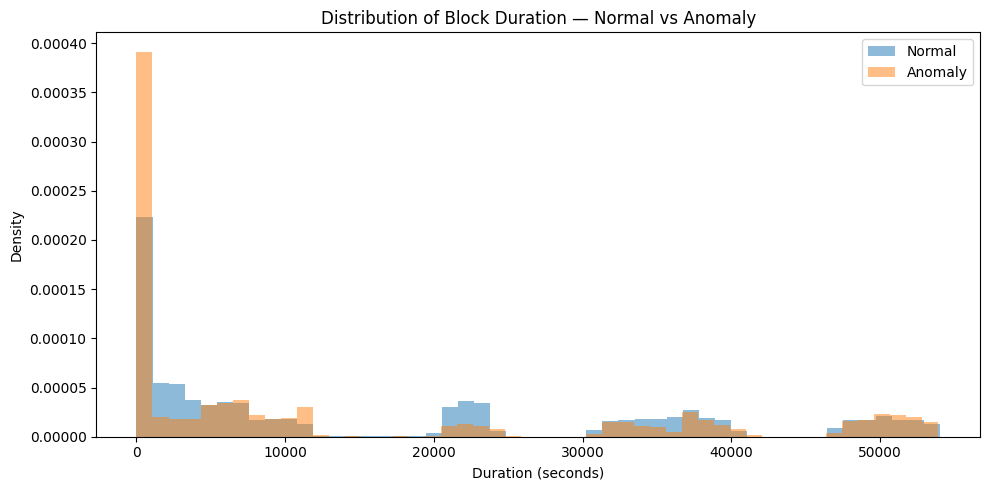

In [19]:
# Plot distribution of block duration — Normal vs Anomaly (log scale)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_time[block_time["Label"] == "Normal"]["duration_seconds"], bins=50, alpha=0.5, label="Normal", density=True)
ax.hist(block_time[block_time["Label"] == "Anomaly"]["duration_seconds"], bins=50, alpha=0.5, label="Anomaly", density=True)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Block Duration — Normal vs Anomaly")
ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS / "block_duration_distribution.png"), dpi=150)
plt.show()

The distributions overlap too much — duration alone won't help the model distinguish well

Let's check if the sequence order matters — what's the first and last template in each block:

In [20]:
# Check first and last template per block — Normal vs Anomaly
first_template = df_full.groupby("block_id")["template_id"].first()
last_template = df_full.groupby("block_id")["template_id"].last()

block_seq = pd.DataFrame({
    "first_template": first_template,
    "last_template": last_template,
    "Label": block_labels
})

print("First template — Normal:")
print(block_seq[block_seq["Label"] == "Normal"]["first_template"].value_counts().head())
print("\nFirst template — Anomaly:")
print(block_seq[block_seq["Label"] == "Anomaly"]["first_template"].value_counts().head())

First template — Normal:
first_template
1     417127
35     85530
2      31082
48     24425
5         56
Name: count, dtype: int64

First template — Anomaly:
first_template
1     10944
35     3866
2      1425
48      587
18       10
Name: count, dtype: int64


Both Normal and Anomaly blocks start mostly with templates 1, 35, 2, 48 — same distribution. Not a useful feature

Let's check the last template — that might be more interesting

In [21]:
# Last template per block — Normal vs Anomaly
print("Last template — Normal:")
print(block_seq[block_seq["Label"] == "Normal"]["last_template"].value_counts().head())
print("\nLast template — Anomaly:")
print(block_seq[block_seq["Label"] == "Anomaly"]["last_template"].value_counts().head())

Last template — Normal:
last_template
17    455995
5      94527
13      5681
4       1294
49       542
Name: count, dtype: int64

Last template — Anomaly:
last_template
17    8603
16    3225
32    1786
1     1307
48     986
Name: count, dtype: int64


Normal blocks almost always end with template 17 or 5 (82% + 17% = 99%).

Anomaly blocks end with a variety:

template 17 — 51% (still most common)
template 16 — 19% (never in normal!)
template 32 — 11% (the error template!)
template 1 — 8%
Insight: If a block ends with template 32 or 16 — very likely anomaly.

Check if normal blocks have a "complete lifecycle" — all expected templates present

In [22]:
# Check which templates appear in almost every normal block
normal_blocks = df_blocks[df_blocks["Label"] == "Normal"]
anomaly_blocks = df_blocks[df_blocks["Label"] == "Anomaly"]

print("Templates present in >90% of Normal blocks:")
for col in template_cols:
    normal_pct = (normal_blocks[col] > 0).mean()
    anomaly_pct = (anomaly_blocks[col] > 0).mean()
    if normal_pct > 0.9:
        print(f"  {col}: Normal {normal_pct:.1%}, Anomaly {anomaly_pct:.1%}")

Templates present in >90% of Normal blocks:
  t_1: Normal 100.0%, Anomaly 100.0%
  t_4: Normal 100.0%, Anomaly 63.1%
  t_5: Normal 100.0%, Anomaly 63.1%


Templates t_1, t_4, t_5 appear in 100% of normal blocks. But:

t_4 — only 63.1% of anomaly blocks have it
t_5 — only 63.1% of anomaly blocks have it
That means 37% of anomaly blocks are missing t_4 and t_5 — they didn't complete the normal lifecycle.

t_1 (Receiving block) appears in all blocks — every block starts. But t_4 and t_5 (completion templates) are missing in anomaly blocks because something went wrong before finishing.

In [23]:
# Find templates that appear exclusively in anomaly blocks
for col in template_cols:
    normal_count = (normal_blocks[col] > 0).sum()
    anomaly_count = (anomaly_blocks[col] > 0).sum()
    if normal_count == 0 and anomaly_count > 0:
        print(f"{col}: Normal 0, Anomaly {anomaly_count}")

t_14: Normal 0, Anomaly 50
t_15: Normal 0, Anomaly 19
t_16: Normal 0, Anomaly 3226
t_18: Normal 0, Anomaly 488
t_19: Normal 0, Anomaly 54
t_20: Normal 0, Anomaly 5
t_22: Normal 0, Anomaly 37
t_23: Normal 0, Anomaly 27
t_24: Normal 0, Anomaly 38
t_25: Normal 0, Anomaly 38
t_26: Normal 0, Anomaly 26
t_27: Normal 0, Anomaly 15
t_28: Normal 0, Anomaly 6
t_29: Normal 0, Anomaly 9
t_30: Normal 0, Anomaly 9
t_39: Normal 0, Anomaly 5
t_40: Normal 0, Anomaly 13
t_41: Normal 0, Anomaly 4
t_42: Normal 0, Anomaly 10
t_43: Normal 0, Anomaly 4
t_44: Normal 0, Anomaly 46
t_45: Normal 0, Anomaly 13
t_46: Normal 0, Anomaly 5
t_51: Normal 0, Anomaly 39
t_52: Normal 0, Anomaly 1
t_53: Normal 0, Anomaly 5
t_54: Normal 0, Anomaly 3
t_55: Normal 0, Anomaly 2


The strongest ones (most appearances):

t_16 — 3,226 anomaly blocks (19%)
t_18 — 488
t_14, t_15, t_19, t_44, t_51 — smaller but still anomaly-only
New feature idea: anomaly_only_template_count — how many anomaly-exclusive templates appear in a block. If any of these 28 templates appear, it's almost certainly anomaly.

Check correlation between templates — do some templates always appear together

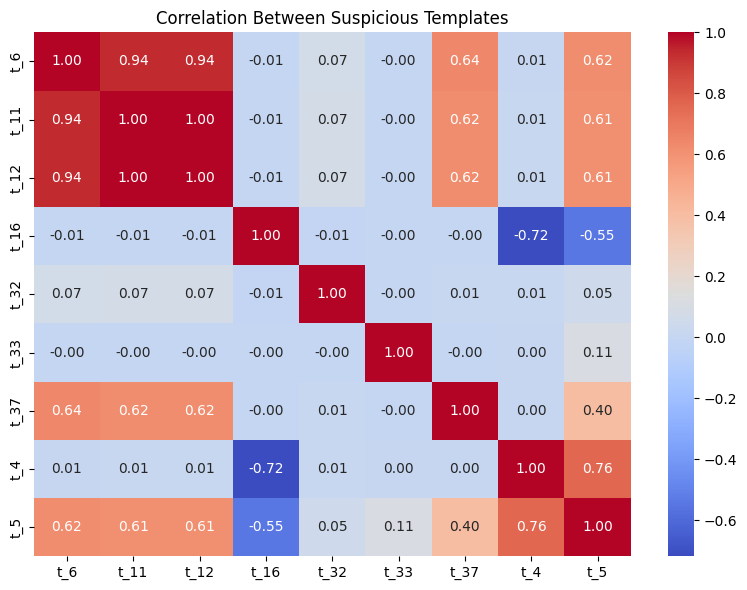

In [24]:
# Correlation between the most interesting templates
interesting = ["t_6", "t_11", "t_12", "t_16", "t_32", "t_33", "t_37", "t_4", "t_5"]
corr = df_blocks[interesting].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Between Suspicious Templates")
plt.tight_layout()
plt.savefig(str(RESULTS / "template_correlation.png"), dpi=150)
plt.show()

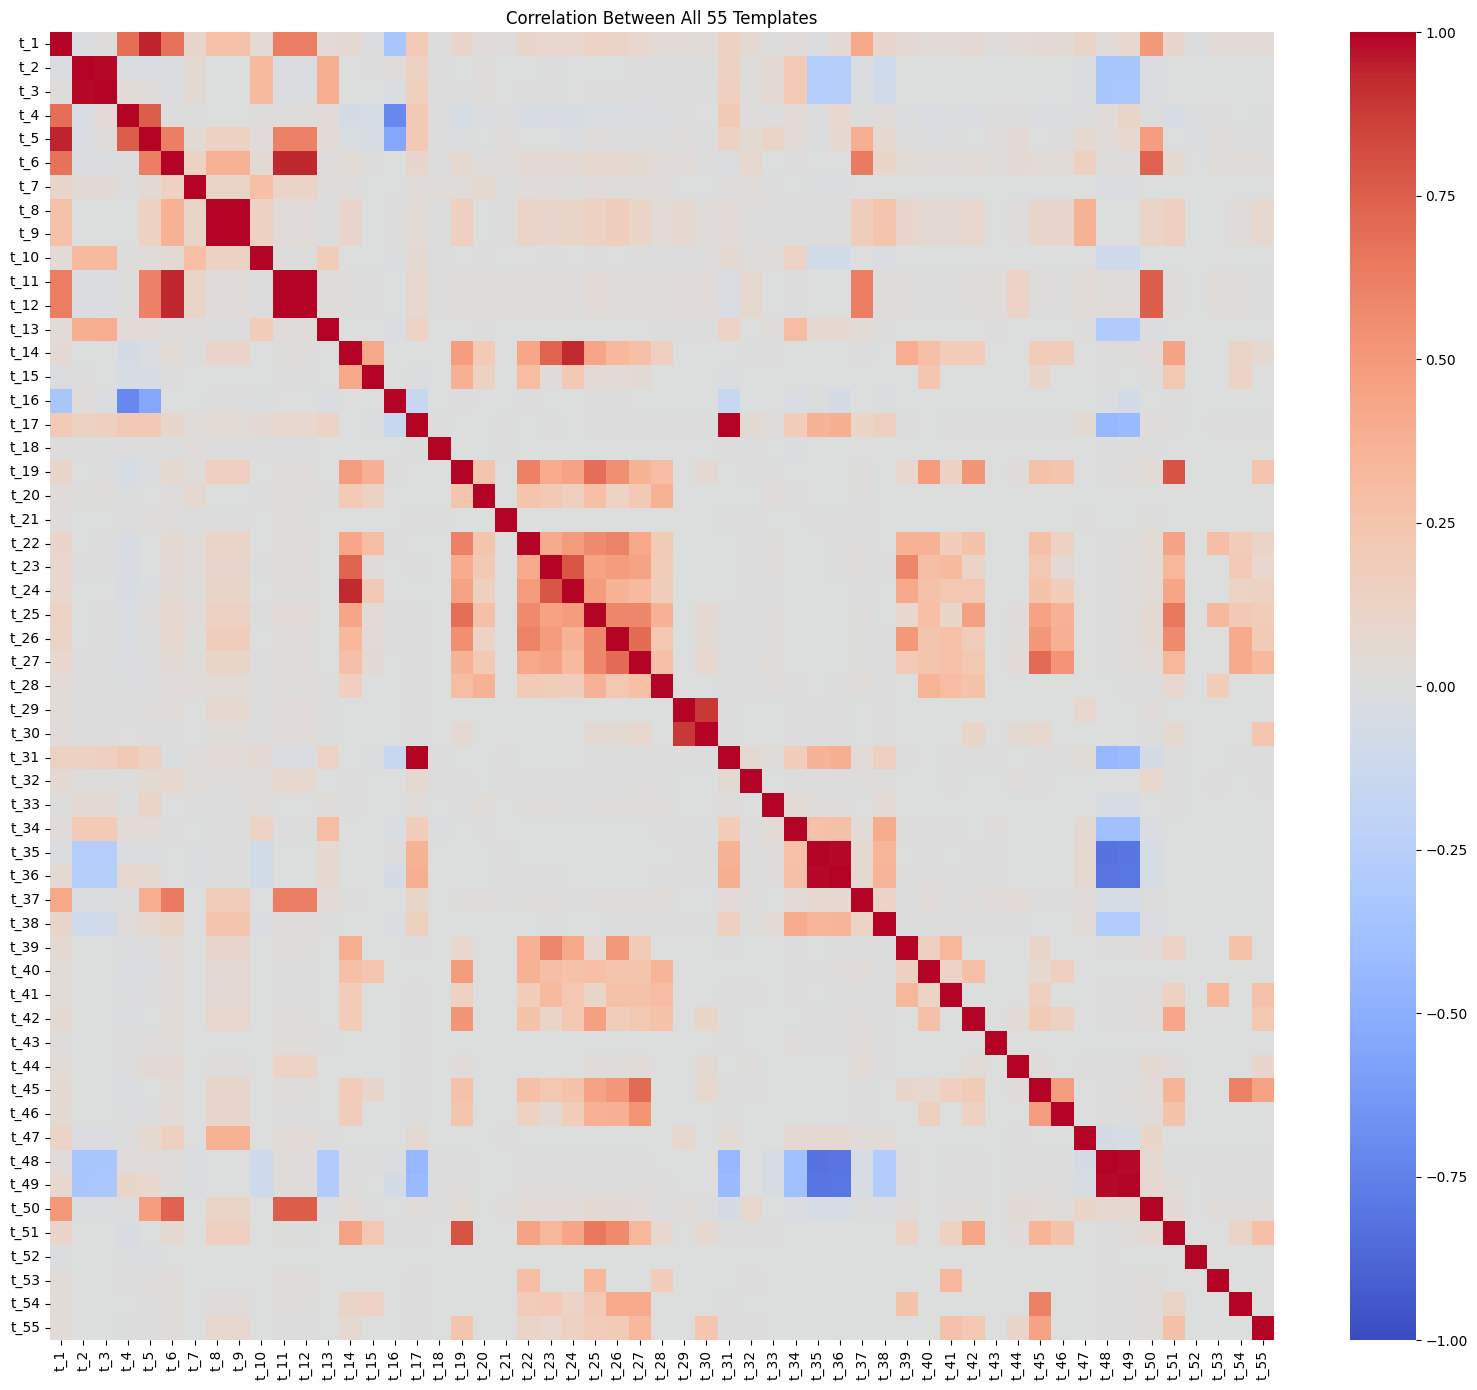

In [25]:
# Correlation heatmap for all templates
corr = df_blocks[template_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Between All 55 Templates")
plt.tight_layout()
plt.savefig(str(RESULTS / "all_templates_correlation.png"), dpi=150)
plt.show()

In [26]:
# Find all highly correlated template pairs
import itertools

pairs = []
for t1, t2 in itertools.combinations(template_cols, 2):
    c = corr.loc[t1, t2]
    if abs(c) > 0.8:
        pairs.append((t1, t2, c))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"Pairs with correlation > 0.8:\n")
for t1, t2, c in pairs:
    print(f"  {t1} — {t2}: {c:.3f}")


Pairs with correlation > 0.8:

  t_8 — t_9: 1.000
  t_11 — t_12: 1.000
  t_17 — t_31: 0.994
  t_48 — t_49: 0.992
  t_35 — t_36: 0.989
  t_2 — t_3: 0.986
  t_1 — t_5: 0.939
  t_6 — t_11: 0.935
  t_6 — t_12: 0.935
  t_14 — t_24: 0.925
  t_29 — t_30: 0.889
  t_35 — t_48: -0.818
  t_35 — t_49: -0.811
  t_36 — t_48: -0.811
  t_36 — t_49: -0.804


In [27]:
# Find templates that rarely appear (in less than 0.1% of all blocks)
print("Rare templates (appear in < 0.1% of blocks):\n")
for col in template_cols:
    pct = (df_blocks[col] > 0).mean()
    if pct < 0.001:
        print(f"  {col}: {pct:.4%} of blocks ({(df_blocks[col] > 0).sum()} blocks)")

Rare templates (appear in < 0.1% of blocks):

  t_7: 0.0285% of blocks (164 blocks)
  t_8: 0.0176% of blocks (101 blocks)
  t_9: 0.0176% of blocks (101 blocks)
  t_14: 0.0087% of blocks (50 blocks)
  t_15: 0.0033% of blocks (19 blocks)
  t_18: 0.0849% of blocks (488 blocks)
  t_19: 0.0094% of blocks (54 blocks)
  t_20: 0.0009% of blocks (5 blocks)
  t_22: 0.0064% of blocks (37 blocks)
  t_23: 0.0047% of blocks (27 blocks)
  t_24: 0.0066% of blocks (38 blocks)
  t_25: 0.0066% of blocks (38 blocks)
  t_26: 0.0045% of blocks (26 blocks)
  t_27: 0.0026% of blocks (15 blocks)
  t_28: 0.0010% of blocks (6 blocks)
  t_29: 0.0016% of blocks (9 blocks)
  t_30: 0.0016% of blocks (9 blocks)
  t_39: 0.0009% of blocks (5 blocks)
  t_40: 0.0023% of blocks (13 blocks)
  t_41: 0.0007% of blocks (4 blocks)
  t_42: 0.0017% of blocks (10 blocks)
  t_43: 0.0007% of blocks (4 blocks)
  t_44: 0.0080% of blocks (46 blocks)
  t_45: 0.0023% of blocks (13 blocks)
  t_46: 0.0009% of blocks (5 blocks)
  t_51: 0.0

In [28]:
# Summary: which templates to keep as individual features
keep = []
drop_correlated = ["t_9", "t_12", "t_31", "t_49", "t_36", "t_3", "t_5", "t_6", "t_24"]

for col in template_cols:
    pct = (df_blocks[col] > 0).mean()
    in_drop = col in drop_correlated
    is_rare = pct < 0.001
    status = "DROP (correlated)" if in_drop else "RARE (use in anomaly_only_count)" if is_rare else "KEEP"
    if status == "KEEP":
        keep.append(col)
    print(f"  {col}: {pct:.2%} — {status}")

print(f"\nKeeping {len(keep)} templates as individual features: {keep}")

  t_1: 100.00% — KEEP
  t_2: 9.90% — KEEP
  t_3: 9.66% — DROP (correlated)
  t_4: 98.92% — KEEP
  t_5: 98.92% — DROP (correlated)
  t_6: 0.91% — DROP (correlated)
  t_7: 0.03% — RARE (use in anomaly_only_count)
  t_8: 0.02% — RARE (use in anomaly_only_count)
  t_9: 0.02% — DROP (correlated)
  t_10: 5.97% — KEEP
  t_11: 0.90% — KEEP
  t_12: 0.90% — DROP (correlated)
  t_13: 14.38% — KEEP
  t_14: 0.01% — RARE (use in anomaly_only_count)
  t_15: 0.00% — RARE (use in anomaly_only_count)
  t_16: 0.56% — KEEP
  t_17: 81.15% — KEEP
  t_18: 0.08% — RARE (use in anomaly_only_count)
  t_19: 0.01% — RARE (use in anomaly_only_count)
  t_20: 0.00% — RARE (use in anomaly_only_count)
  t_21: 0.17% — KEEP
  t_22: 0.01% — RARE (use in anomaly_only_count)
  t_23: 0.00% — RARE (use in anomaly_only_count)
  t_24: 0.01% — DROP (correlated)
  t_25: 0.01% — RARE (use in anomaly_only_count)
  t_26: 0.00% — RARE (use in anomaly_only_count)
  t_27: 0.00% — RARE (use in anomaly_only_count)
  t_28: 0.00% — RARE (